# 03 · Modelado y Evaluación
## Proyecto: Estimador de Capacidad de Pago — Sector Informal (ENIGH 2024)

Este notebook está organizado **por modelo**: cada algoritmo
(Regresión Logística, Random Forest, Red Neuronal) tiene su propia sección
con un bloque de **hiperparámetros explícito y editable** al inicio, seguido
del entrenamiento y evaluación para los dos umbrales de ingreso
(`clase_ingreso_15k` y `clase_ingreso_mediana`).

**Cómo usar este notebook:**

1. Corre las secciones 0–2 (configuración, funciones y preparación de datos)
   una sola vez.
2. En cada sección de modelo, edita el diccionario de hiperparámetros
   (`hiperparametros_*`) con los valores que quieras probar y vuelve a
   correr esa sección — no es necesario re-ejecutar las demás.
3. Para la Red Neuronal hay además dos celdas opcionales de **búsqueda de
   hiperparámetros**: `GridSearchCV` (búsqueda exhaustiva en una malla) y
   `RandomizedSearchCV` (búsqueda aleatoria sobre distribuciones). Son útiles
   para explorar combinaciones automáticamente antes de fijar los valores
   finales en `hiperparametros_mlp`.
4. La sección final (**Comparación de modelos**) consolida resultados,
   matrices de confusión, curvas ROC e importancia de variables de los tres
   modelos.
5. Las dos últimas secciones son los análisis de sensibilidad
   (`est_socio_num` y balanceo de clases).


## 0. Configuración inicial y carga de datos

In [41]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
from scipy.stats import uniform, randint

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


In [42]:
df_ml = pd.read_csv(DATA_PROCESSED / "concentradohogar_procesado.csv")
print(f"Filas: {df_ml.shape[0]:,}  |  Columnas: {df_ml.shape[1]}")
df_ml.head()


Filas: 91,414  |  Columnas: 17


,folioviv,foliohog,edad_jefe,clase_ingreso_15k,clase_ingreso_mediana,tasa_dependencia,nivel_urbano,educa_num,es_mujer_jefa,est_socio_num,region_Centro_Norte,region_Norte,region_Sur,clase_hog_2,clase_hog_3,clase_hog_4,clase_hog_5
0,100001901,1,32,1,1,2.000000,4,6,0,3,1,0,0,1,0,0,0
1,100001902,1,48,1,1,2.000000,4,9,0,3,1,0,0,1,0,0,0
2,100001904,1,60,1,0,1.000000,4,6,1,3,1,0,0,1,0,0,0
3,100001905,1,43,1,1,1.333333,4,8,0,3,1,0,0,1,0,0,0
4,100002501,1,29,1,1,2.000000,4,8,1,2,1,0,0,1,0,0,0


## 1. Funciones auxiliares

In [43]:
TARGETS = {
    "clase_ingreso_15k": "$15,000 MXN/mes (\u2248 2 salarios m\u00ednimos, CONASAMI)",
    "clase_ingreso_mediana": "Mediana muestral (\u2248 LPI urbana, CONEVAL)",
}
DROP_TARGETS = list(TARGETS.keys())
ID_COLS = ["folioviv", "foliohog"]


def preparar_X_y(df, target_col, include_est_socio=True):
    '''Devuelve X (predictoras) y y (objetivo) para un target dado.'''
    feature_cols = [c for c in df.columns if c not in DROP_TARGETS + ID_COLS]
    if not include_est_socio and "est_socio_num" in feature_cols:
        feature_cols = [c for c in feature_cols if c != "est_socio_num"]
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y


def escalar(X_train, X_test):
    '''Estandariza todas las columnas (ajustado solo con train).'''
    scaler = StandardScaler()
    X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
    return X_train_s, X_test_s, scaler


def oversample_clase_minoritaria(X, y, random_state=RANDOM_STATE):
    '''Sobremuestreo simple (con reemplazo) de la clase minoritaria.'''
    tmp = X.copy()
    tmp["_y"] = y.values
    conteos = tmp["_y"].value_counts()
    n_max = conteos.max()

    partes = []
    for clase, n in conteos.items():
        parte = tmp[tmp["_y"] == clase]
        if n < n_max:
            parte = resample(parte, replace=True, n_samples=n_max, random_state=random_state)
        partes.append(parte)

    balanceado = pd.concat(partes).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanceado.drop(columns="_y"), balanceado["_y"]


def evaluar_modelo(modelo, X_train, y_train, X_test, y_test):
    '''Entrena y evalúa un modelo; devuelve un diccionario con métricas.'''
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else None

    reporte = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    return {
        "modelo_obj": modelo,
        "accuracy": reporte["accuracy"],
        "precision_0": reporte["0"]["precision"], "recall_0": reporte["0"]["recall"], "f1_0": reporte["0"]["f1-score"],
        "precision_1": reporte["1"]["precision"], "recall_1": reporte["1"]["recall"], "f1_1": reporte["1"]["f1-score"],
        "f1_macro": reporte["macro avg"]["f1-score"],
        "auc": auc,
        "cm": cm,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


def resumen_cv(modelo, X, y, cv=5):
    '''Validación cruzada estratificada; devuelve medias y desviaciones.'''
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        modelo, X, y, cv=skf,
        scoring=["accuracy", "f1_macro", "roc_auc"],
        n_jobs=-1
    )
    out = {}
    for key in ["test_accuracy", "test_f1_macro", "test_roc_auc"]:
        out[f"{key}_mean"] = scores[key].mean()
        out[f"{key}_std"] = scores[key].std()
    return out


# Diccionarios donde se acumulan resultados de TODOS los modelos
resultados_principales = []   # filas para la tabla comparativa final
modelos_entrenados = {}       # (target, nombre_modelo) -> {res, Xtr, Xte}


def registrar_resultado(target_col, nombre_modelo, modelo, X_train, y_train, X_test, y_test, hacer_cv=True):
    '''Entrena, evalúa, corre CV (opcional) y guarda el resultado en las
    estructuras globales `resultados_principales` y `modelos_entrenados`.'''
    res = evaluar_modelo(modelo, X_train, y_train, X_test, y_test)
    modelos_entrenados[(target_col, nombre_modelo)] = dict(res=res, Xtr=X_train, Xte=X_test)

    fila = {
        "target": target_col,
        "modelo": nombre_modelo,
        "test_accuracy": res["accuracy"],
        "test_recall_0": res["recall_0"], "test_recall_1": res["recall_1"],
        "test_f1_macro": res["f1_macro"], "test_auc": res["auc"],
    }

    if hacer_cv:
        cv = resumen_cv(modelo, X_train, y_train, cv=5)
        fila.update({
            "cv_accuracy_mean": cv["test_accuracy_mean"], "cv_accuracy_std": cv["test_accuracy_std"],
            "cv_f1_macro_mean": cv["test_f1_macro_mean"], "cv_f1_macro_std": cv["test_f1_macro_std"],
            "cv_auc_mean": cv["test_roc_auc_mean"], "cv_auc_std": cv["test_roc_auc_std"],
        })

    resultados_principales.append(fila)

    print(f"[{target_col} | {nombre_modelo}] "
          f"accuracy={res['accuracy']:.3f}  recall_0={res['recall_0']:.3f}  "
          f"recall_1={res['recall_1']:.3f}  AUC={res['auc']:.3f}")
    return res


## 2. Preparación de datos

Se realiza, para cada umbral, la partición 80/20 estratificada y el
escalado de variables (`StandardScaler`, ajustado solo con el conjunto de
entrenamiento). El resultado se guarda en el diccionario `splits` para que
cada sección de modelo lo reutilice.

- `X_train` / `X_test`: variables **sin escalar** (usadas por Random Forest).
- `X_train_s` / `X_test_s`: variables **escaladas** (usadas por Regresión
  Logística y Red Neuronal).

In [44]:
splits = {}

for target_col, target_label in TARGETS.items():
    X, y = preparar_X_y(df_ml, target_col, include_est_socio=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train_s, X_test_s, _ = escalar(X_train, X_test)

    splits[target_col] = dict(
        X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
        X_train_s=X_train_s, X_test_s=X_test_s,
    )

    print(f"{target_col:25s} -> train={X_train.shape[0]:6d}  test={X_test.shape[0]:6d}  "
          f"({target_label})")


clase_ingreso_15k         -> train= 73131  test= 18283  ($15,000 MXN/mes (≈ 2 salarios mínimos, CONASAMI))
clase_ingreso_mediana     -> train= 73131  test= 18283  (Mediana muestral (≈ LPI urbana, CONEVAL))


## 3. MODELO 1 — Regresión Logística

### 3.1 Hiperparámetros

Edita los valores de este diccionario y vuelve a correr esta sección para
probar otras configuraciones. Los hiperparámetros más relevantes de
`LogisticRegression` son:

- **`penalty`**: tipo de regularización (`'l2'`, `'l1'`, `'elasticnet'`, `None`).
- **`C`**: inverso de la fuerza de regularización (valores más pequeños =
  más regularización).
- **`solver`**: algoritmo de optimización (`'lbfgs'`, `'liblinear'`,
  `'saga'`, ...). No todos los solvers soportan todas las penalizaciones.
- **`max_iter`**: número máximo de iteraciones para que converja.
- **`class_weight`**: `'balanced'` para compensar el desbalance de clases,
  o `None` para desactivarlo.

In [45]:
hiperparametros_logreg = {
    "penalty": "l2",
    "C": 1.0,
    "solver": "lbfgs",
    "max_iter": 1000,
    "class_weight": "balanced",   # 'balanced' o None
    "random_state": RANDOM_STATE,
}

print("Hiperparámetros Regresión Logística:")
for k, v in hiperparametros_logreg.items():
    print(f"  {k}: {v}")


Hiperparámetros Regresión Logística:
  penalty: l2
  C: 1.0
  solver: lbfgs
  max_iter: 1000
  class_weight: balanced
  random_state: 42


### 3.2 Entrenamiento y evaluación (ambos umbrales)

In [46]:
for target_col, target_label in TARGETS.items():
    sp = splits[target_col]
    modelo_logreg = LogisticRegression(**hiperparametros_logreg)
    # Regresión Logística usa variables ESCALADAS
    registrar_resultado(
        target_col, "Regresión Logística", modelo_logreg,
        sp["X_train_s"], sp["y_train"], sp["X_test_s"], sp["y_test"],
    )


[clase_ingreso_15k | Regresión Logística] accuracy=0.717  recall_0=0.731  recall_1=0.708  AUC=0.800
[clase_ingreso_mediana | Regresión Logística] accuracy=0.720  recall_0=0.722  recall_1=0.718  AUC=0.798


## 4. MODELO 2 — Random Forest

### 4.1 Hiperparámetros

Hiperparámetros más relevantes de `RandomForestClassifier`:

- **`n_estimators`**: número de árboles del bosque.
- **`max_depth`**: profundidad máxima de cada árbol (`None` = sin límite).
- **`min_samples_split`**: mínimo de muestras para dividir un nodo.
- **`min_samples_leaf`**: mínimo de muestras en una hoja.
- **`max_features`**: número de variables consideradas en cada división
  (`'sqrt'`, `'log2'`, un entero, o `None` para usar todas).
- **`class_weight`**: `'balanced'` para compensar el desbalance de clases,
  o `None` para desactivarlo.

In [47]:
hiperparametros_rf = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "class_weight": "balanced",   # 'balanced' o None
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

print("Hiperparámetros Random Forest:")
for k, v in hiperparametros_rf.items():
    print(f"  {k}: {v}")


Hiperparámetros Random Forest:
  n_estimators: 200
  max_depth: None
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: sqrt
  class_weight: balanced
  random_state: 42
  n_jobs: -1


### 4.2 Entrenamiento y evaluación (ambos umbrales)

In [48]:
for target_col, target_label in TARGETS.items():
    sp = splits[target_col]
    modelo_rf = RandomForestClassifier(**hiperparametros_rf)
    # Random Forest usa variables SIN ESCALAR
    registrar_resultado(
        target_col, "Random Forest", modelo_rf,
        sp["X_train"], sp["y_train"], sp["X_test"], sp["y_test"],
    )


[clase_ingreso_15k | Random Forest] accuracy=0.703  recall_0=0.595  recall_1=0.769  AUC=0.762
[clase_ingreso_mediana | Random Forest] accuracy=0.685  recall_0=0.690  recall_1=0.679  AUC=0.758


### 4.3 Búsqueda de hiperparámetros — `GridSearchCV` (opcional)

Igual que con la Red Neuronal, `GridSearchCV` prueba **todas las
combinaciones** de `param_grid_rf` usando validación cruzada. Se ejecuta
sobre `clase_ingreso_15k` como ejemplo (variable `TARGET_BUSQUEDA`, ya
definida más adelante en la sección de la Red Neuronal — si corres esta
celda antes, defínela aquí también).

Hiperparámetros incluidos en la malla:

- **`n_estimators`**: número de árboles.
- **`max_depth`**: profundidad máxima de cada árbol (`None` = sin límite).
- **`min_samples_leaf`**: mínimo de muestras por hoja (controla
  sobreajuste; valores más altos = árboles más simples).
- **`max_features`**: variables consideradas en cada división
  (`'sqrt'`, `'log2'`).

Al terminar, copia `grid_rf.best_params_` a `hiperparametros_rf` (sección
4.1) y vuelve a correr la sección 4.2 para evaluarlos sobre el conjunto de
prueba.

In [49]:
TARGET_BUSQUEDA = "clase_ingreso_15k"
sp_busqueda = splits[TARGET_BUSQUEDA]

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

# Random Forest usa variables SIN ESCALAR
grid_rf.fit(sp_busqueda["X_train"], sp_busqueda["y_train"])

print("\n--- GridSearchCV (Random Forest) ---")
print("Mejores hiperparámetros:", grid_rf.best_params_)
print(f"Mejor AUC (validación cruzada): {grid_rf.best_score_:.4f}")

resultados_grid_rf = pd.DataFrame(grid_rf.cv_results_)
resultados_grid_rf = resultados_grid_rf[["params", "mean_test_score", "std_test_score"]]
resultados_grid_rf = resultados_grid_rf.sort_values("mean_test_score", ascending=False)
resultados_grid_rf.head(5)


Fitting 3 folds for each of 72 candidates, totalling 216 fits

--- GridSearchCV (Random Forest) ---
Mejores hiperparámetros: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
Mejor AUC (validación cruzada): 0.8169


,params,mean_test_score,std_test_score
71,"{'max_depth': 20, 'max_features': 'log2', 'min...",0.816864,0.002194
62,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.816864,0.002194
70,"{'max_depth': 20, 'max_features': 'log2', 'min...",0.816680,0.002277
61,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.816680,0.002277
17,"{'max_depth': None, 'max_features': 'log2', 'm...",0.816553,0.002017


### 4.4 Búsqueda de hiperparámetros — `RandomizedSearchCV` (opcional)

`RandomizedSearchCV` muestrea aleatoriamente `n_iter` combinaciones de
`param_dist_rf`. Aquí se usan distribuciones discretas (`randint`) para los
parámetros enteros, lo que permite explorar un rango más amplio que en
`GridSearchCV` sin que el costo computacional crezca tanto.

Edita `param_dist_rf` y `n_iter` según el tiempo disponible. Igual que en
las celdas anteriores, `random_rf.best_params_` indica la mejor combinación
encontrada — cópiala a `hiperparametros_rf` (sección 4.1) y vuelve a correr
la sección 4.2.

In [50]:
param_dist_rf = {
    "n_estimators": randint(100, 400),
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
}

random_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=15,           # número de combinaciones aleatorias a probar
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

# Random Forest usa variables SIN ESCALAR
random_rf.fit(sp_busqueda["X_train"], sp_busqueda["y_train"])

print("\n--- RandomizedSearchCV (Random Forest) ---")
print("Mejores hiperparámetros:", random_rf.best_params_)
print(f"Mejor AUC (validación cruzada): {random_rf.best_score_:.4f}")

resultados_random_rf = pd.DataFrame(random_rf.cv_results_)
resultados_random_rf = resultados_random_rf[["params", "mean_test_score", "std_test_score"]]
resultados_random_rf = resultados_random_rf.sort_values("mean_test_score", ascending=False)
resultados_random_rf.head(5)


Fitting 3 folds for each of 15 candidates, totalling 45 fits

--- RandomizedSearchCV (Random Forest) ---
Mejores hiperparámetros: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 221}
Mejor AUC (validación cruzada): 0.8191


,params,mean_test_score,std_test_score
0,"{'max_depth': 15, 'max_features': 'sqrt', 'min...",0.819130,0.002270
11,"{'max_depth': 15, 'max_features': 'log2', 'min...",0.819029,0.002410
7,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.818523,0.002095
6,"{'max_depth': 15, 'max_features': 'sqrt', 'min...",0.817472,0.002113
8,"{'max_depth': 15, 'max_features': 'log2', 'min...",0.817184,0.002165


## 5. MODELO 3 — Red Neuronal (MLPClassifier)

### 5.1 Hiperparámetros

Hiperparámetros más relevantes de `MLPClassifier`:

- **`hidden_layer_sizes`**: tupla con el número de neuronas por capa oculta,
  p. ej. `(64, 32)` = dos capas ocultas de 64 y 32 neuronas.
- **`activation`**: función de activación (`'relu'`, `'tanh'`, `'logistic'`).
- **`solver`**: algoritmo de optimización (`'adam'`, `'sgd'`, `'lbfgs'`).
- **`alpha`**: término de regularización L2.
- **`learning_rate_init`**: tasa de aprendizaje inicial (relevante para
  `'adam'`/`'sgd'`).
- **`max_iter`**: número máximo de épocas de entrenamiento.
- **`early_stopping`**: si `True`, detiene el entrenamiento cuando deja de
  mejorar en un subconjunto de validación interno.

> Nota: `MLPClassifier` **no admite** el parámetro `class_weight`. El
> tratamiento del desbalance para este modelo se analiza por separado en la
> sección de sensibilidad al balanceo de clases (sobremuestreo).

In [51]:
hiperparametros_mlp = {
    "hidden_layer_sizes": (64, 32),
    "activation": "relu",
    "solver": "adam",
    "alpha": 0.0001,
    "learning_rate_init": 0.001,
    "max_iter": 500,
    "early_stopping": True,
    "random_state": RANDOM_STATE,
}

print("Hiperparámetros Red Neuronal (MLP):")
for k, v in hiperparametros_mlp.items():
    print(f"  {k}: {v}")


Hiperparámetros Red Neuronal (MLP):
  hidden_layer_sizes: (64, 32)
  activation: relu
  solver: adam
  alpha: 0.0001
  learning_rate_init: 0.001
  max_iter: 500
  early_stopping: True
  random_state: 42


### 5.2 Entrenamiento y evaluación (ambos umbrales)

In [52]:
for target_col, target_label in TARGETS.items():
    sp = splits[target_col]
    modelo_mlp = MLPClassifier(**hiperparametros_mlp)
    # Red Neuronal usa variables ESCALADAS
    registrar_resultado(
        target_col, "Red Neuronal (MLP)", modelo_mlp,
        sp["X_train_s"], sp["y_train"], sp["X_test_s"], sp["y_test"],
    )


[clase_ingreso_15k | Red Neuronal (MLP)] accuracy=0.747  recall_0=0.628  recall_1=0.820  AUC=0.814
[clase_ingreso_mediana | Red Neuronal (MLP)] accuracy=0.730  recall_0=0.734  recall_1=0.726  AUC=0.810


### 5.3 Búsqueda de hiperparámetros — `GridSearchCV` (opcional)

`GridSearchCV` prueba **todas las combinaciones posibles** de los valores
indicados en `param_grid`, usando validación cruzada. Es exhaustivo pero
puede ser lento si la malla es grande. Se ejecuta sobre el umbral
`clase_ingreso_15k` como ejemplo; cambia `TARGET_BUSQUEDA` si quieres usar
el otro umbral.

Edita `param_grid_mlp` con los valores que quieras explorar. Al final,
`grid_mlp.best_params_` indica la mejor combinación encontrada — puedes
copiar esos valores a `hiperparametros_mlp` (sección 5.1) y volver a correr
la sección 5.2 para evaluarlos sobre el conjunto de prueba.

In [53]:
TARGET_BUSQUEDA = "clase_ingreso_15k"
sp_busqueda = splits[TARGET_BUSQUEDA]

param_grid_mlp = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(
        solver="adam", max_iter=500, early_stopping=True, random_state=RANDOM_STATE
    ),
    param_grid=param_grid_mlp,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_mlp.fit(sp_busqueda["X_train_s"], sp_busqueda["y_train"])

print("\n--- GridSearchCV ---")
print("Mejores hiperparámetros:", grid_mlp.best_params_)
print(f"Mejor AUC (validación cruzada): {grid_mlp.best_score_:.4f}")

# Top 5 combinaciones probadas, ordenadas por desempeño
resultados_grid = pd.DataFrame(grid_mlp.cv_results_)
resultados_grid = resultados_grid[["params", "mean_test_score", "std_test_score"]]
resultados_grid = resultados_grid.sort_values("mean_test_score", ascending=False)
resultados_grid.head(5)


Fitting 3 folds for each of 24 candidates, totalling 72 fits

--- GridSearchCV ---
Mejores hiperparámetros: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (128, 64)}
Mejor AUC (validación cruzada): 0.8162


,params,mean_test_score,std_test_score
23,"{'activation': 'tanh', 'alpha': 0.01, 'hidden_...",0.816244,0.001906
15,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.815041,0.002466
19,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.814691,0.002529
3,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.814074,0.001661
11,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.813869,0.001506


### 5.4 Búsqueda de hiperparámetros — `RandomizedSearchCV` (opcional)

`RandomizedSearchCV` toma una muestra **aleatoria** de `n_iter` combinaciones
de hiperparámetros (pueden ser listas de valores discretos o distribuciones
continuas como `scipy.stats.uniform`). Es más rápido que `GridSearchCV`
cuando el espacio de búsqueda es grande, a cambio de no garantizar explorar
todas las combinaciones.

Edita `param_dist_mlp` y `n_iter` según el tiempo disponible. Igual que en
`GridSearchCV`, `random_mlp.best_params_` indica la mejor combinación
encontrada.

In [54]:
param_dist_mlp = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64), (100, 50, 25)],
    "activation": ["relu", "tanh"],
    "alpha": uniform(0.0001, 0.01),            # distribución continua [0.0001, 0.0101)
    "learning_rate_init": uniform(0.0005, 0.01),  # distribución continua [0.0005, 0.0105)
}

random_mlp = RandomizedSearchCV(
    estimator=MLPClassifier(
        solver="adam", max_iter=500, early_stopping=True, random_state=RANDOM_STATE
    ),
    param_distributions=param_dist_mlp,
    n_iter=15,           # número de combinaciones aleatorias a probar
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

random_mlp.fit(sp_busqueda["X_train_s"], sp_busqueda["y_train"])

print("\n--- RandomizedSearchCV ---")
print("Mejores hiperparámetros:", random_mlp.best_params_)
print(f"Mejor AUC (validación cruzada): {random_mlp.best_score_:.4f}")

resultados_random = pd.DataFrame(random_mlp.cv_results_)
resultados_random = resultados_random[["params", "mean_test_score", "std_test_score"]]
resultados_random = resultados_random.sort_values("mean_test_score", ascending=False)
resultados_random.head(5)


Fitting 3 folds for each of 15 candidates, totalling 45 fits

--- RandomizedSearchCV ---
Mejores hiperparámetros: {'activation': 'tanh', 'alpha': np.float64(0.0019223608778806234), 'hidden_layer_sizes': (128, 64), 'learning_rate_init': np.float64(0.0036171107608941096)}
Mejor AUC (validación cruzada): 0.8166


,params,mean_test_score,std_test_score
13,"{'activation': 'tanh', 'alpha': 0.001922360877...",0.816612,0.001781
4,"{'activation': 'tanh', 'alpha': 0.002223391106...",0.815527,0.002807
5,"{'activation': 'tanh', 'alpha': 0.006216531604...",0.814367,0.001856
7,"{'activation': 'tanh', 'alpha': 0.003763618432...",0.814343,0.000507
8,"{'activation': 'tanh', 'alpha': 0.006024145688...",0.814088,0.000942


## 6. Comparación de modelos

Esta sección consolida los resultados registrados por las secciones
anteriores (`resultados_principales` y `modelos_entrenados`). Si vuelves a
correr alguna sección de modelo con otros hiperparámetros, vuelve a correr
también esta sección para actualizar la comparación.

In [55]:
tabla_resultados = pd.DataFrame(resultados_principales)

# Si se corrió más de una vez la misma combinación target/modelo, nos
# quedamos con el resultado más reciente
tabla_resultados = tabla_resultados.drop_duplicates(
    subset=["target", "modelo"], keep="last"
).reset_index(drop=True)

tabla_resultados_fmt = tabla_resultados.copy()
for col in tabla_resultados_fmt.select_dtypes(include="float").columns:
    tabla_resultados_fmt[col] = tabla_resultados_fmt[col].round(3)

tabla_resultados_fmt


,target,modelo,test_accuracy,test_recall_0,test_recall_1,test_f1_macro,test_auc,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_auc_mean,cv_auc_std
0,clase_ingreso_15k,Regresión Logística,0.717,0.731,0.708,0.710,0.800,0.722,0.002,0.715,0.001,0.802,0.002
1,clase_ingreso_mediana,Regresión Logística,0.720,0.722,0.718,0.720,0.798,0.726,0.003,0.726,0.003,0.801,0.004
2,clase_ingreso_15k,Random Forest,0.703,0.595,0.769,0.683,0.762,0.708,0.004,0.689,0.004,0.768,0.002
3,clase_ingreso_mediana,Random Forest,0.685,0.690,0.679,0.685,0.758,0.692,0.003,0.692,0.003,0.764,0.003
4,clase_ingreso_15k,Red Neuronal (MLP),0.747,0.628,0.820,0.727,0.814,0.745,0.002,0.723,0.003,0.812,0.004
5,clase_ingreso_mediana,Red Neuronal (MLP),0.730,0.734,0.726,0.730,0.810,0.734,0.004,0.734,0.004,0.813,0.005


### 6.1 Matrices de confusión (todos los modelos y umbrales)

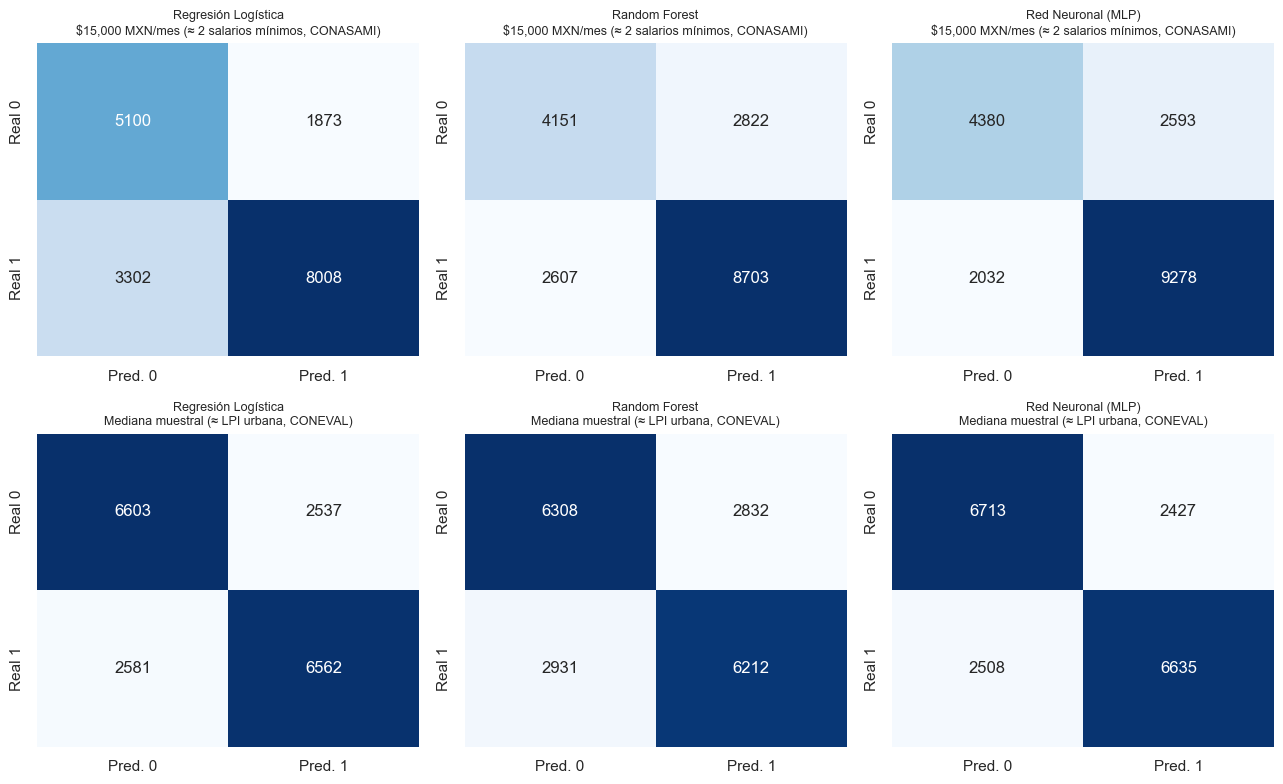

In [56]:
nombres_modelos = ["Regresión Logística", "Random Forest", "Red Neuronal (MLP)"]

fig, axes = plt.subplots(len(TARGETS), len(nombres_modelos), figsize=(13, 8))

for i, (target_col, target_label) in enumerate(TARGETS.items()):
    for j, nombre_modelo in enumerate(nombres_modelos):
        clave = (target_col, nombre_modelo)
        if clave not in modelos_entrenados:
            axes[i, j].axis("off")
            axes[i, j].set_title(f"{nombre_modelo}\n(sin entrenar)", fontsize=9)
            continue

        cm = modelos_entrenados[clave]["res"]["cm"]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i, j],
                     xticklabels=["Pred. 0", "Pred. 1"], yticklabels=["Real 0", "Real 1"])
        axes[i, j].set_title(f"{nombre_modelo}\n{target_label}", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "05_matrices_confusion.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.2 Curvas ROC (todos los modelos y umbrales)

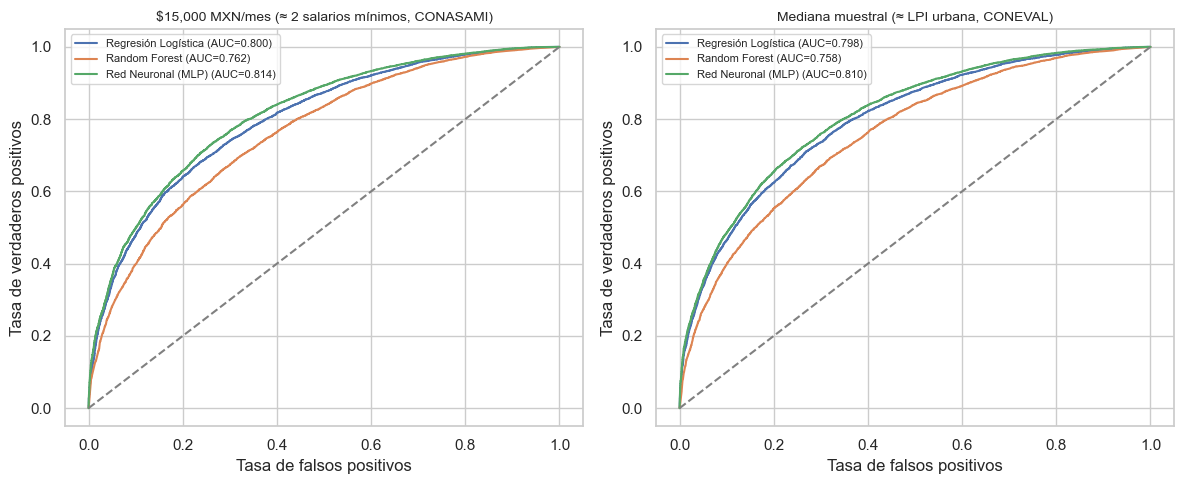

In [57]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(12, 5))

for ax, (target_col, target_label) in zip(axes, TARGETS.items()):
    for nombre_modelo in nombres_modelos:
        clave = (target_col, nombre_modelo)
        if clave not in modelos_entrenados:
            continue
        res = modelos_entrenados[clave]["res"]
        y_test = splits[target_col]["y_test"]
        fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
        ax.plot(fpr, tpr, label=f"{nombre_modelo} (AUC={res['auc']:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_title(target_label, fontsize=10)
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "06_curvas_roc.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.3 Importancia de variables

- **Regresión Logística**: coeficientes estandarizados.
- **Random Forest**: `feature_importances_` (reducción promedio de impureza).
- **Red Neuronal (MLP)**: importancia por permutación
  (`permutation_importance`).

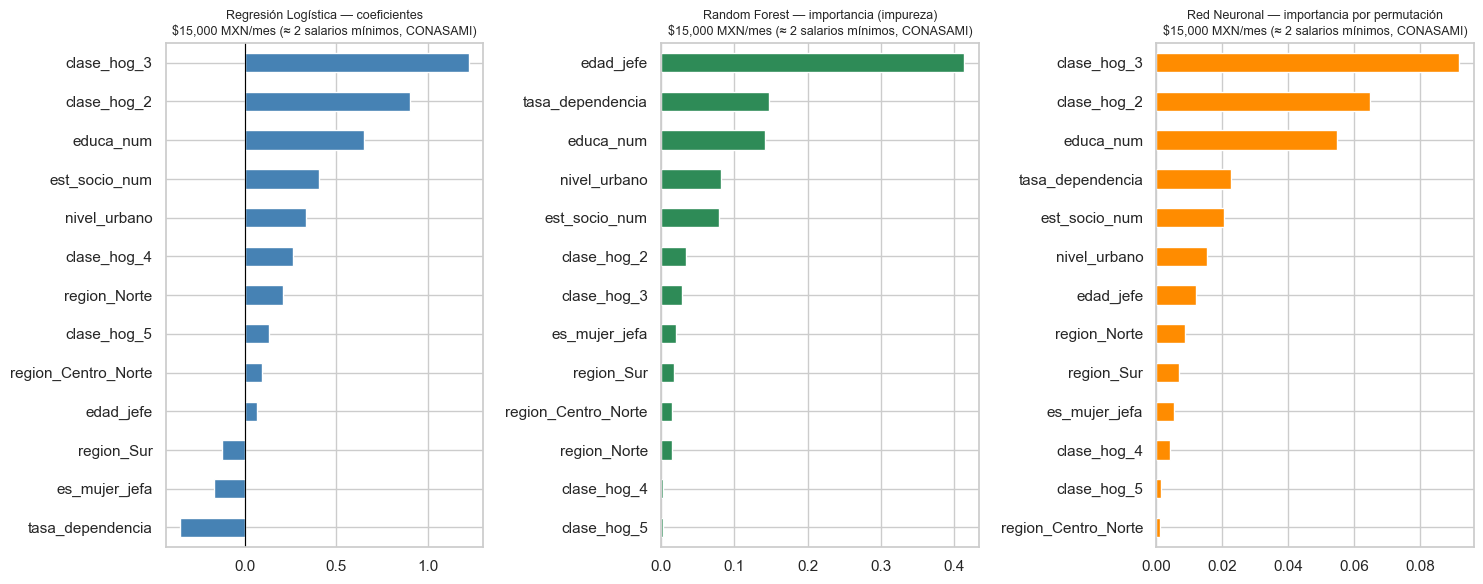

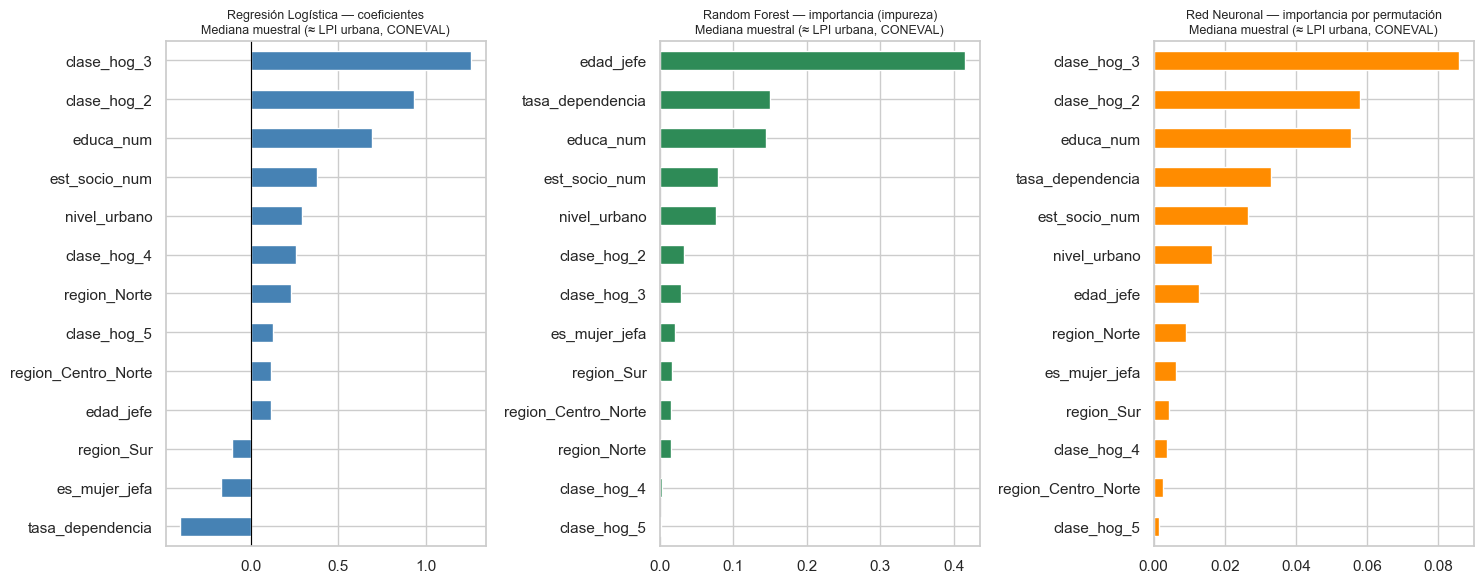

In [58]:
def graficar_importancia_logreg(ax, target_col):
    info = modelos_entrenados.get((target_col, "Regresión Logística"))
    if info is None:
        ax.axis("off"); return
    modelo = info["res"]["modelo_obj"]
    coefs = pd.Series(modelo.coef_[0], index=info["Xtr"].columns).sort_values()
    coefs.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Regresión Logística — coeficientes\n{TARGETS[target_col]}", fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)


def graficar_importancia_rf(ax, target_col):
    info = modelos_entrenados.get((target_col, "Random Forest"))
    if info is None:
        ax.axis("off"); return
    modelo = info["res"]["modelo_obj"]
    imp = pd.Series(modelo.feature_importances_, index=info["Xtr"].columns).sort_values()
    imp.plot(kind="barh", ax=ax, color="seagreen")
    ax.set_title(f"Random Forest — importancia (impureza)\n{TARGETS[target_col]}", fontsize=9)


def graficar_importancia_mlp(ax, target_col, n_repeats=5):
    info = modelos_entrenados.get((target_col, "Red Neuronal (MLP)"))
    if info is None:
        ax.axis("off"); return
    modelo = info["res"]["modelo_obj"]
    Xte, y_test = info["Xte"], splits[target_col]["y_test"]
    result = permutation_importance(modelo, Xte, y_test, n_repeats=n_repeats,
                                      random_state=RANDOM_STATE, n_jobs=-1)
    imp = pd.Series(result.importances_mean, index=Xte.columns).sort_values()
    imp.plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title(f"Red Neuronal — importancia por permutación\n{TARGETS[target_col]}", fontsize=9)


for target_col in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    graficar_importancia_logreg(axes[0], target_col)
    graficar_importancia_rf(axes[1], target_col)
    graficar_importancia_mlp(axes[2], target_col)
    plt.tight_layout()
    plt.savefig(FIGURES / f"07_importancia_variables_{target_col}.png", dpi=120, bbox_inches="tight")
    plt.show()


## 7. Análisis de sensibilidad: `est_socio_num`

Se compara, para cada umbral, el modelo con **mejor AUC** registrado en la
sección 6, entrenado con y sin `est_socio_num`. Usa los mismos
hiperparámetros definidos en la sección del modelo correspondiente
(`hiperparametros_logreg`, `hiperparametros_rf` o `hiperparametros_mlp`).

In [59]:
CONSTRUCTORES = {
    "Regresión Logística": lambda: LogisticRegression(**hiperparametros_logreg),
    "Random Forest": lambda: RandomForestClassifier(**hiperparametros_rf),
    "Red Neuronal (MLP)": lambda: MLPClassifier(**hiperparametros_mlp),
}
USA_ESCALADO = {
    "Regresión Logística": True,
    "Random Forest": False,
    "Red Neuronal (MLP)": True,
}

resultados_est_socio = []

for target_col, target_label in TARGETS.items():
    sub = tabla_resultados[tabla_resultados["target"] == target_col]
    mejor_modelo_nombre = sub.loc[sub["test_auc"].idxmax(), "modelo"]

    for include_est_socio, etiqueta in [(True, "Con est_socio_num"), (False, "Sin est_socio_num")]:
        X, y = preparar_X_y(df_ml, target_col, include_est_socio=include_est_socio)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
        )
        X_train_s, X_test_s, _ = escalar(X_train, X_test)

        modelo = CONSTRUCTORES[mejor_modelo_nombre]()
        if USA_ESCALADO[mejor_modelo_nombre]:
            Xtr, Xte = X_train_s, X_test_s
        else:
            Xtr, Xte = X_train, X_test

        res = evaluar_modelo(modelo, Xtr, y_train, Xte, y_test)

        resultados_est_socio.append({
            "target": target_col,
            "modelo": mejor_modelo_nombre,
            "variante": etiqueta,
            "accuracy": res["accuracy"],
            "recall_0": res["recall_0"], "recall_1": res["recall_1"],
            "f1_macro": res["f1_macro"], "auc": res["auc"],
        })

tabla_est_socio = pd.DataFrame(resultados_est_socio)
tabla_est_socio.round(3)


,target,modelo,variante,accuracy,recall_0,recall_1,f1_macro,auc
0,clase_ingreso_15k,Red Neuronal (MLP),Con est_socio_num,0.747,0.628,0.820,0.727,0.814
1,clase_ingreso_15k,Red Neuronal (MLP),Sin est_socio_num,0.747,0.639,0.814,0.729,0.813
2,clase_ingreso_mediana,Red Neuronal (MLP),Con est_socio_num,0.730,0.734,0.726,0.730,0.810
3,clase_ingreso_mediana,Red Neuronal (MLP),Sin est_socio_num,0.726,0.740,0.711,0.726,0.805


## 8. Análisis de sensibilidad: balanceo de clases (`clase_ingreso_15k`)

Para el umbral con mayor desbalance (≈38% / 62%), se compara cada modelo
**sin balanceo** vs. **con balanceo**, usando los mismos hiperparámetros
base definidos en sus secciones respectivas (solo se cambia
`class_weight` para Regresión Logística/Random Forest, o se aplica
sobremuestreo para la Red Neuronal).

In [60]:
TARGET_BALANCEO = "clase_ingreso_15k"
sp = splits[TARGET_BALANCEO]
resultados_balanceo = []

# --- Regresión Logística ---
for balanceado, etiqueta in [(False, "Sin balanceo"), (True, "Con balanceo")]:
    params = {**hiperparametros_logreg, "class_weight": "balanced" if balanceado else None}
    modelo = LogisticRegression(**params)
    res = evaluar_modelo(modelo, sp["X_train_s"], sp["y_train"], sp["X_test_s"], sp["y_test"])
    resultados_balanceo.append({
        "modelo": "Regresión Logística", "variante": etiqueta,
        "accuracy": res["accuracy"], "recall_0": res["recall_0"], "recall_1": res["recall_1"],
        "f1_macro": res["f1_macro"], "auc": res["auc"],
    })

# --- Random Forest ---
for balanceado, etiqueta in [(False, "Sin balanceo"), (True, "Con balanceo")]:
    params = {**hiperparametros_rf, "class_weight": "balanced" if balanceado else None}
    modelo = RandomForestClassifier(**params)
    res = evaluar_modelo(modelo, sp["X_train"], sp["y_train"], sp["X_test"], sp["y_test"])
    resultados_balanceo.append({
        "modelo": "Random Forest", "variante": etiqueta,
        "accuracy": res["accuracy"], "recall_0": res["recall_0"], "recall_1": res["recall_1"],
        "f1_macro": res["f1_macro"], "auc": res["auc"],
    })

# --- Red Neuronal (MLP): sin class_weight -> se usa sobremuestreo ---
for balanceado, etiqueta in [(False, "Sin balanceo"), (True, "Con balanceo")]:
    modelo = MLPClassifier(**hiperparametros_mlp)
    if balanceado:
        Xtr_fit, ytr_fit = oversample_clase_minoritaria(sp["X_train_s"], sp["y_train"])
    else:
        Xtr_fit, ytr_fit = sp["X_train_s"], sp["y_train"]
    res = evaluar_modelo(modelo, Xtr_fit, ytr_fit, sp["X_test_s"], sp["y_test"])
    resultados_balanceo.append({
        "modelo": "Red Neuronal (MLP)", "variante": etiqueta,
        "accuracy": res["accuracy"], "recall_0": res["recall_0"], "recall_1": res["recall_1"],
        "f1_macro": res["f1_macro"], "auc": res["auc"],
    })

tabla_balanceo = pd.DataFrame(resultados_balanceo)
tabla_balanceo.round(3)


,modelo,variante,accuracy,recall_0,recall_1,f1_macro,auc
0,Regresión Logística,Sin balanceo,0.734,0.571,0.834,0.708,0.800
1,Regresión Logística,Con balanceo,0.717,0.731,0.708,0.710,0.800
2,Random Forest,Sin balanceo,0.704,0.574,0.784,0.681,0.761
3,Random Forest,Con balanceo,0.703,0.595,0.769,0.683,0.762
4,Red Neuronal (MLP),Sin balanceo,0.747,0.628,0.820,0.727,0.814
5,Red Neuronal (MLP),Con balanceo,0.728,0.753,0.712,0.721,0.812


## 9. Guardar resultados

In [61]:
tabla_resultados_fmt.to_csv(REPORTS / "resultados_modelado_principal.csv", index=False)
tabla_est_socio.round(3).to_csv(REPORTS / "resultados_sensibilidad_est_socio.csv", index=False)
tabla_balanceo.round(3).to_csv(REPORTS / "resultados_sensibilidad_balanceo.csv", index=False)

print("✅ Tablas guardadas en reports/:")
print(" - resultados_modelado_principal.csv")
print(" - resultados_sensibilidad_est_socio.csv")
print(" - resultados_sensibilidad_balanceo.csv")


✅ Tablas guardadas en reports/:
 - resultados_modelado_principal.csv
 - resultados_sensibilidad_est_socio.csv
 - resultados_sensibilidad_balanceo.csv
